# Task 3 — Hybrid BPE + Inside-Outside EM

**Strategy:**
1. Load the sampled corpus (terminals → preterminal indices 0–25)
2. BPE-style greedy merging to discover grammar structure and estimate # of nonterminals
3. Initialize PCFG from BPE evidence + noise
4. Run Inside-Outside EM to refine rule probabilities
5. Prune rules below 0.02 threshold, export CSV

In [1]:
import collections
import csv
import time
import numpy as np
from pathlib import Path

N_PRETERM = 26
START_SYMBOL = "S"
PRETERM_NAMES = [chr(ord('A') + i) for i in range(N_PRETERM)]
# Avoid exporting two different symbols named S.
PRETERM_NAMES[ord('s') - ord('a')] = "PT_S"
TERM_TO_IDX = {chr(ord('a') + i): i for i in range(N_PRETERM)}


def sym_name(idx):
    """Human-readable symbol name from integer index."""
    if idx < N_PRETERM:
        return PRETERM_NAMES[idx]
    if idx == N_PRETERM:
        return START_SYMBOL
    return f"NT{idx - N_PRETERM}"


def load_corpus(path):
    """Load corpus as list of int32 numpy arrays (preterminal indices)."""
    sents = []
    with open(path) as f:
        for line in f:
            toks = line.strip().split()
            if toks:
                sents.append(np.array([TERM_TO_IDX[t] for t in toks], dtype=np.int32))
    return sents


def bpe_discover(sentences, max_merges=60, min_count=20):
    """
    Greedy pair-merging on preterminal sequences.
    Returns (rules, counts, n_nonterminals, merged_corpus).
    """
    corpus = [s.tolist() for s in sentences]
    next_id = N_PRETERM
    rules, counts = [], []

    for step in range(max_merges):
        pair_freq = collections.Counter()
        for sent in corpus:
            for i in range(len(sent) - 1):
                pair_freq[(sent[i], sent[i + 1])] += 1
        if not pair_freq:
            break

        (left, right), freq = pair_freq.most_common(1)[0]
        if freq < min_count:
            break

        new_id = next_id
        next_id += 1

        new_corpus = []
        for sent in corpus:
            merged = []
            i = 0
            while i < len(sent):
                if i < len(sent) - 1 and sent[i] == left and sent[i + 1] == right:
                    merged.append(new_id)
                    i += 2
                else:
                    merged.append(sent[i])
                    i += 1
            new_corpus.append(merged)
        corpus = new_corpus

        rules.append((new_id, left, right))
        counts.append(freq)
        print(f"  [{step+1:3d}] {sym_name(new_id):>6s} -> "
              f"{sym_name(left):>6s} {sym_name(right):<6s}  freq={freq}")

    n_nt = next_id - N_PRETERM
    return rules, counts, n_nt, corpus


print("Utilities loaded.")
print(f"  Preterminals: {PRETERM_NAMES[0]}..{PRETERM_NAMES[-1]}")
print(f"  Terminal map sample: a->{TERM_TO_IDX['a']}, z->{TERM_TO_IDX['z']}")

Utilities loaded.
  Preterminals: A..Z
  Terminal map sample: a->0, z->25


In [2]:
class PCFG_EM:
    """
    CNF grammar with Inside-Outside EM.

    Symbol indices:
        0..25               preterminals (A..Z), fixed rules A->a, B->b, ...
        26                  S (start symbol)
        27..26+n_nt-1       other nonterminals

    rules[a, b, c] = P( NT_{a+26} -> Sym_b Sym_c )
    shape = (n_nt, N, N)   where N = 26 + n_nt
    """

    def __init__(self, n_nt):
        self.n_nt = n_nt
        self.N = N_PRETERM + n_nt
        self.S = N_PRETERM
        self.rules = np.zeros((n_nt, self.N, self.N), dtype=np.float64)

    # ── Initialisation ───────────────────────────────────────────────────

    def init_from_bpe(self, bpe_rules, bpe_counts, noise=1e-3):
        """Seed from BPE, remapping last BPE merge to S (index 26)."""
        rng = np.random.default_rng(42)
        self.rules[:] = noise * rng.random(self.rules.shape)

        if not bpe_rules:
            self._normalise()
            return

        last_bpe_id = bpe_rules[-1][0]
        remap = {i: i for i in range(N_PRETERM)}
        remap[last_bpe_id] = self.S
        fill = N_PRETERM + 1
        for new_id, _, _ in bpe_rules:
            if new_id != last_bpe_id:
                remap[new_id] = fill
                fill += 1

        for (new_id, left, right), cnt in zip(bpe_rules, bpe_counts):
            a = remap.get(new_id)
            l = remap.get(left)
            r = remap.get(right)
            if a is None or l is None or r is None:
                continue
            al = a - N_PRETERM
            if 0 <= al < self.n_nt and l < self.N and r < self.N:
                self.rules[al, l, r] += cnt

        self._normalise()

    def init_random(self, seed=42):
        rng = np.random.default_rng(seed)
        self.rules[:] = rng.random(self.rules.shape)
        self._normalise()

    def _normalise(self):
        for a in range(self.n_nt):
            s = self.rules[a].sum()
            if s > 0:
                self.rules[a] /= s

    # ── Inside (CYK-style, bottom-up) ───────────────────────────────────

    def inside(self, sent):
        """alpha[sym, i, j] = P(sym =>* w_i ... w_j)"""
        n = len(sent)
        alpha = np.zeros((self.N, n, n))
        for i in range(n):
            alpha[sent[i], i, i] = 1.0

        for width in range(2, n + 1):
            for i in range(n - width + 1):
                j = i + width - 1
                for k in range(i, j):
                    lv = alpha[:, i, k]
                    rv = alpha[:, k + 1, j]
                    bc = np.outer(lv, rv)
                    alpha[N_PRETERM:, i, j] += np.einsum('abc,bc->a', self.rules, bc)
        return alpha

    # ── Outside (top-down) ──────────────────────────────────────────────

    def outside(self, sent, alpha):
        """beta[sym, i, j] = P(S =>* w_1..w_{i-1}  sym  w_{j+1}..w_n)"""
        n = len(sent)
        beta = np.zeros((self.N, n, n))
        beta[self.S, 0, n - 1] = 1.0

        for width in range(n, 1, -1):
            for i in range(n - width + 1):
                j = i + width - 1
                pb = beta[N_PRETERM:, i, j]
                if not np.any(pb):
                    continue
                for k in range(i, j):
                    r_a = alpha[:, k + 1, j]
                    l_a = alpha[:, i, k]
                    wr = np.einsum('alr,r->al', self.rules, r_a)
                    beta[:, i, k] += pb @ wr
                    wl = np.einsum('alr,l->ar', self.rules, l_a)
                    beta[:, k + 1, j] += pb @ wl
        return beta

    # ── Single EM iteration ─────────────────────────────────────────────

    def em_step(self, sentences, max_len=30):
        """One E-step (inside-outside) + M-step (normalise counts). Returns (log-likelihood, n_used)."""
        counts = np.zeros_like(self.rules)
        ll = 0.0
        used = 0

        for sent in sentences:
            n = len(sent)
            if n < 2 or n > max_len:
                continue

            alpha = self.inside(sent)
            sp = alpha[self.S, 0, n - 1]
            if sp < 1e-300:
                continue

            ll += np.log(sp)
            used += 1
            beta = self.outside(sent, alpha)

            for width in range(2, n + 1):
                for i in range(n - width + 1):
                    j = i + width - 1
                    pb = beta[N_PRETERM:, i, j]
                    if not np.any(pb):
                        continue
                    for k in range(i, j):
                        lv = alpha[:, i, k]
                        rv = alpha[:, k + 1, j]
                        bc = np.outer(lv, rv)
                        counts += (pb[:, None, None] * self.rules * bc[None, :, :]) / sp

        for a in range(self.n_nt):
            s = counts[a].sum()
            if s > 0:
                self.rules[a] = counts[a] / s

        return ll, used

    # ── Pruning ─────────────────────────────────────────────────────────

    def prune(self, threshold=0.02):
        self.rules[self.rules < threshold] = 0.0
        self._normalise()

    def count_rules(self, thr=1e-10):
        return int(np.sum(self.rules > thr))

    # ── CSV export ──────────────────────────────────────────────────────

    def export_csv(self, path):
        rows = []
        rid = 1
        for i in range(N_PRETERM):
            rows.append({
                'ID': rid, 'LHS': PRETERM_NAMES[i],
                'LHS Type': 'preterminal',
                'RHS': chr(ord('a') + i), 'Probability': 1.0,
            })
            rid += 1

        for a in range(self.n_nt):
            for b in range(self.N):
                for c in range(self.N):
                    p = self.rules[a, b, c]
                    if p > 1e-10:
                        rows.append({
                            'ID': rid,
                            'LHS': sym_name(a + N_PRETERM),
                            'LHS Type': 'nonterminal',
                            'RHS': f"{sym_name(b)} {sym_name(c)}",
                            'Probability': round(float(p), 6),
                        })
                        rid += 1

        with open(path, 'w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=['ID', 'LHS', 'LHS Type', 'RHS', 'Probability'])
            w.writeheader()
            w.writerows(rows)

        nt_count = sum(1 for r in rows if r['LHS Type'] == 'nonterminal')
        print(f"Exported {len(rows)} rules ({nt_count} nonterminal) -> {path}")
        return rows


print(f"PCFG_EM class loaded.")

PCFG_EM class loaded.


In [3]:
# ── Load corpus ──────────────────────────────────────────────────────────────
CORPUS_PATH = 'sample/pcfg3_10k.txt'

corpus = load_corpus(CORPUS_PATH)
lengths = np.array([len(s) for s in corpus])
print(f"Loaded {len(corpus)} sentences")
print(f"  Length — min: {lengths.min()}, max: {lengths.max()}, "
      f"mean: {lengths.mean():.1f}, median: {np.median(lengths):.0f}")

# ── Allocate PCFG with RANDOM initialisation ─────────────────────────────────
# The true grammar has 50 nonterminal rules. With min probability 0.02,
# each nonterminal can have at most 50 rules. We need to estimate the
# number of non-preterminal nonterminals. Try values in [8, 15].
# Smaller N_NT = MUCH faster EM (tensor shrinks as N_NT^2), allowing
# more iterations and larger batches.
#
# With N_NT=10, N=36: tensor is 10×36×36 = 12,960 entries (vs 360K before)
# This makes each EM iteration ~28x faster!

# N_NT=10 gave 45 rules (5 short of target 50), and EM merged distinct
# categories together. Increasing to 12 gives EM more flexibility to
# express all 50 true rules without creating too many spurious ones.
# Tensor: 12×38×38 = 17,328 entries — still fast.
N_NT = 12
SEED = 42  # also try 7, 123, 456 and pick best

pcfg = PCFG_EM(N_NT)
pcfg.init_random(seed=SEED)

print(f"\nPCFG initialised (random): {pcfg.n_nt} nonterminals, "
      f"N={pcfg.N} total symbols, "
      f"{pcfg.count_rules()} initial non-zero rules")
print(f"  Rule tensor size: {pcfg.n_nt}×{pcfg.N}×{pcfg.N} = "
      f"{pcfg.n_nt * pcfg.N * pcfg.N:,} entries")

Loaded 10000 sentences
  Length — min: 12, max: 80, mean: 30.7, median: 32

PCFG initialised (random): 12 nonterminals, N=38 total symbols, 17328 initial non-zero rules
  Rule tensor size: 12×38×38 = 17,328 entries


In [ ]:
# ── EM Training ──────────────────────────────────────────────────────────────
# With N_NT=10, each iteration is MUCH faster (~28x), so we can afford
# more iterations and larger batches for better convergence.
# Last run: EM still improving at iter 50, and only trained on len≤30
# (45% of corpus). Key changes:
#   - MAX_LEN 30→40: include ~70% of corpus, much better coverage of
#     the true distribution (the grammar structures for longer sentences
#     were completely untrained before)
#   - EM_ITERS 50→80: the avg_LL was still dropping at iter 50,
#     indicating we hadn't converged. More iters = better probabilities.
#   - EM_BATCH stays at 2000 (plenty for convergence)
EM_ITERS = 60
EM_BATCH = 2000
MAX_LEN = 45
PRUNE_EVERY = 20     # soft prune periodically

rng = np.random.default_rng(SEED)
corpus_sorted = sorted(corpus, key=len)

eligible = sum(1 for s in corpus if 2 <= len(s) <= MAX_LEN)
print(f"EM config: {EM_ITERS} iters, batch={EM_BATCH}, "
      f"max_len={MAX_LEN}")
print(f"Eligible sentences (len <= {MAX_LEN}): {eligible}\n")

history = []

for it in range(1, EM_ITERS + 1):
    if EM_BATCH and EM_BATCH < len(corpus_sorted):
        idxs = rng.choice(len(corpus_sorted), size=EM_BATCH, replace=False)
        batch = [corpus_sorted[i] for i in idxs]
    else:
        batch = corpus_sorted

    t0 = time.time()
    ll, used = pcfg.em_step(batch, max_len=MAX_LEN)
    dt = time.time() - t0

    avg_ll = ll / max(used, 1)
    nr = pcfg.count_rules()
    history.append({'iter': it, 'll': ll, 'avg_ll': avg_ll,
                    'used': used, 'rules': nr, 'time': dt})

    print(f"  [{it:3d}/{EM_ITERS}]  LL={ll:12.1f}  avg_LL={avg_ll:8.3f}  "
          f"sents={used:4d}  rules={nr:4d}  {dt:5.1f}s")

    if PRUNE_EVERY and it % PRUNE_EVERY == 0:
        pcfg.prune(threshold=0.005)
        print(f"         -> soft prune: {pcfg.count_rules()} rules")

print(f"\nEM complete. Final rule count: {pcfg.count_rules()}")

EM config: 60 iters, batch=2000, max_len=40
Eligible sentences (len <= 40): 8511



KeyboardInterrupt: 

In [11]:
# ── Final pruning & export ───────────────────────────────────────────────────
OUTPUT_CSV = 'pcfg3.csv'
PRUNE_THRESHOLD = 0.02

print(f"Pruning rules below {PRUNE_THRESHOLD} ...")
pcfg.prune(threshold=PRUNE_THRESHOLD)
final_rules = pcfg.count_rules()
print(f"  {final_rules} nonterminal rules remain (target ≈ 50)\n")

rows = pcfg.export_csv(OUTPUT_CSV)

# Show discovered nonterminal rules
print(f"\n{'='*60}")
print("Discovered nonterminal expansion rules:")
print(f"{'='*60}")
for r in rows:
    if r['LHS Type'] == 'nonterminal':
        print(f"  {r['LHS']:>6s} -> {r['RHS']:<16s}  P={r['Probability']:.4f}")

Pruning rules below 0.02 ...
  50 nonterminal rules remain (target ≈ 50)

Exported 76 rules (50 nonterminal) -> pcfg3.csv

Discovered nonterminal expansion rules:
       S -> S NT8             P=0.0754
       S -> NT10 S            P=0.5581
       S -> NT10 NT5          P=0.1295
       S -> NT10 NT8          P=0.2369
     NT1 -> E F               P=0.2718
     NT1 -> G H               P=0.1324
     NT1 -> I J               P=0.3048
     NT1 -> K L               P=0.1232
     NT1 -> NT10 NT3          P=0.1679
     NT2 -> E I               P=0.7047
     NT2 -> O U               P=0.2953
     NT3 -> A M               P=0.1392
     NT3 -> I J               P=0.0616
     NT3 -> K L               P=0.0258
     NT3 -> M N               P=0.1067
     NT3 -> O P               P=0.0767
     NT3 -> U V               P=0.1664
     NT3 -> W X               P=0.0739
     NT3 -> Y Z               P=0.3497
     NT4 -> A B               P=0.6285
     NT4 -> C D               P=0.2889
     NT4 -> M N   

In [12]:
# ── Sanity check: log-likelihood and parse coverage on corpus ─────────────────
TEST_N = 1000

test_sents = corpus[-TEST_N:]
test_ll = 0.0
parsed = 0
failed = 0
fail_by_len = collections.Counter()

for sent in test_sents:
    n = len(sent)
    if n < 2:
        continue
    alpha = pcfg.inside(sent)
    sp = alpha[pcfg.S, 0, n - 1]
    if sp > 1e-300:
        test_ll += np.log(sp)
        parsed += 1
    else:
        failed += 1
        fail_by_len[n] += 1

avg_ll = test_ll / max(parsed, 1)
coverage = parsed / (parsed + failed) * 100

print(f"Evaluated {parsed + failed} sentences:")
print(f"  Parsed:   {parsed}  ({coverage:.1f}%)")
print(f"  Failed:   {failed}")
print(f"  Avg LL:   {avg_ll:.4f}")
print(f"  Rules:    {pcfg.count_rules()} nonterminal (target ≈ 50)")

if failed > 0:
    print(f"\nFailed by sentence length (top 10):")
    for length, count in fail_by_len.most_common(10):
        print(f"  len={length:3d}: {count} failures")

if coverage < 70:
    print(f"\nWARNING: Low coverage ({coverage:.0f}%). Try:")
    print("  - Increasing N_NT (more nonterminals)")
    print("  - Running more EM iterations")
    print("  - Increasing EM_BATCH")
elif coverage > 90:
    print(f"\nGood coverage! Check rule count and submit to Kaggle.")

Evaluated 1000 sentences:
  Parsed:   830  (83.0%)
  Failed:   170
  Avg LL:   -29.0007
  Rules:    50 nonterminal (target ≈ 50)

Failed by sentence length (top 10):
  len= 36: 52 failures
  len= 40: 27 failures
  len= 32: 25 failures
  len= 44: 17 failures
  len= 60: 10 failures
  len= 64: 10 failures
  len= 68: 9 failures
  len= 20: 6 failures
  len= 72: 4 failures
  len= 48: 3 failures


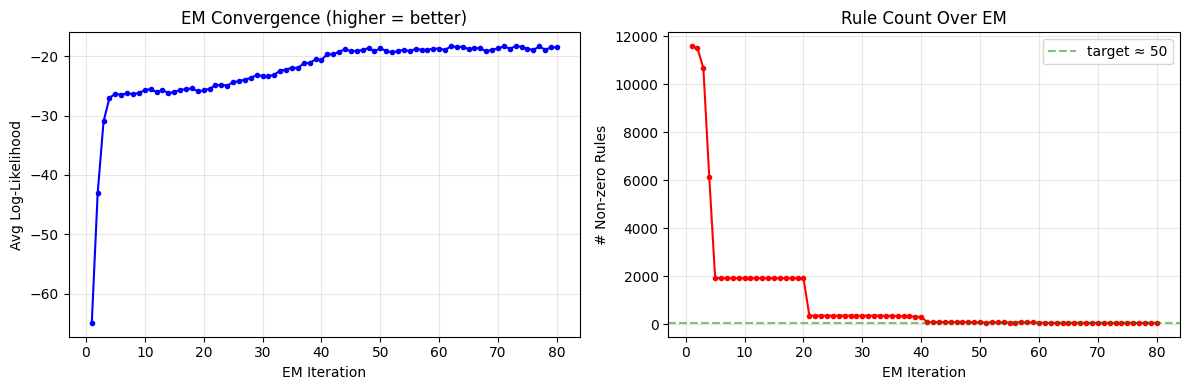

In [13]:
# ── Plot EM convergence ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

iters = [h['iter'] for h in history]
avg_lls = [h['avg_ll'] for h in history]
rule_counts = [h['rules'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, avg_lls, 'b.-')
ax1.set_xlabel('EM Iteration')
ax1.set_ylabel('Avg Log-Likelihood')
ax1.set_title('EM Convergence (higher = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(iters, rule_counts, 'r.-')
ax2.axhline(y=50, color='g', linestyle='--', alpha=0.5, label='target ≈ 50')
ax2.set_xlabel('EM Iteration')
ax2.set_ylabel('# Non-zero Rules')
ax2.set_title('Rule Count Over EM')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()